In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0]))

from scipy.stats import chi2
from statsmodels.graphics.tsaplots import plot_acf
from src.utils.config import load_config
from src.data.loaders import load_prices
from src.data.features import compute_log_returns
from src.portfolio.pnl import compute_portfolio_pnl
from src.portfolio.positions import Portfolio
from src.backtest.kupiec import kupiec_test
from src.backtest.christoffersen import (
    christoffersen_test,
    christoffersen_conditional_coverage_test
)
from src.backtest.diagnostics import (
    plot_var_vs_loss,
    plot_exceptions,
    exception_summary,
    plot_var_comparison,
    plot_exception_counts
)

In [2]:
portfolio_cfg = load_config(Path("../configs/portfolio.yaml"))
risk_cfg = load_config(Path("../configs/risk.yaml"))

tickers = portfolio_cfg["portfolio"]["tickers"]
notional = portfolio_cfg["portfolio"]["notional"]

prices = load_prices(
    tickers,
    start=risk_cfg["risk"]["start_date"],
    end=risk_cfg["risk"]["end_date"]
)

returns = compute_log_returns(prices)

portfolio = Portfolio.from_equal_weight(
    tickers=tickers,
    notional=notional
)

pnl = compute_portfolio_pnl(returns, portfolio)

Cached prices available
Cached data covers request. Loading from cache.


### Rolling Backtest

In [3]:
bt_hist = pd.read_parquet("../data/processed/historical_backtest.parquet")

bt_ewma = pd.read_parquet("../data/processed/parametric_ewma_backtest.parquet")

bt_mc_sample = pd.read_parquet("../data/processed/mc_sample_backtest.parquet")

bt_mc_ewma = pd.read_parquet("../data/processed/mc_ewma_backtest.parquet")

bt_fhs = pd.read_parquet("../data/processed/fhs_backtest.parquet")

# Results summary
print("Rolling backtest results:")
print("Historical Exceptions:", bt_hist["Exception"].sum())
print("Parametric EWMA Exceptions:", bt_ewma["Exception"].sum())
print("Monte Carlo Sample Exceptions:", bt_mc_sample["Exception"].sum())
print("Monte Carlo EWMA Exceptions:", bt_mc_ewma["Exception"].sum())
print("FHS Exceptions:", bt_fhs["Exception"].sum())

Rolling backtest results:
Historical Exceptions: 50
Parametric EWMA Exceptions: 69
Monte Carlo Sample Exceptions: 94
Monte Carlo EWMA Exceptions: 81
FHS Exceptions: 33


### Kupiec and Christoffersen Test

In [9]:
models = ["Historical", "Parametric EWMA", "Monte Carlo Sample", "Monte Carlo EWMA", "FHS"]
dfs = [bt_hist, bt_ewma, bt_mc_sample, bt_mc_ewma, bt_fhs]

kup_result = {"Historical": kupiec_test(bt_hist, alpha=0.99),
          "Parametric EWMA": kupiec_test(bt_ewma, alpha=0.99),
          "Monte Carlo Sample": kupiec_test(bt_mc_sample, alpha=0.99),
          "Monte Carlo EWMA": kupiec_test(bt_mc_ewma, alpha=0.99),
          "FHS": kupiec_test(bt_fhs, alpha=0.99)}

kup_result_df = pd.DataFrame(kup_result).T.reset_index()
kup_result_df = kup_result_df.rename(columns={"index": "Model"})

chris_result = {"Historical": christoffersen_test(bt_hist),
            "Parametric EWMA": christoffersen_test(bt_ewma),
            "Monte Carlo Sample": christoffersen_test(bt_mc_sample),
            "Monte Carlo EWMA": christoffersen_test(bt_mc_ewma),
            "FHS": christoffersen_test(bt_fhs)}

chris_result_df = pd.DataFrame(chris_result).T.reset_index()
chris_result_df = chris_result_df.rename(columns={"index": "Model"})

print("Kupiec Test Results:")
print(kup_result_df)
print("Christoffersen Independence Test Results:")
print(chris_result_df)

chris_cond_cov_result = [{"Model": model, **christoffersen_conditional_coverage_test(df, alpha=0.99)} for model, df in zip(models, dfs)]
print("Christoffersen Conditional Coverage Test Results:")
print(pd.DataFrame(chris_cond_cov_result))

Kupiec Test Results:
                Model  exceptions  observations         LR       p_value
0          Historical        50.0        3173.0   9.042507  2.637737e-03
1     Parametric EWMA        69.0        3173.0  33.108412  8.716082e-09
2  Monte Carlo Sample        94.0        3173.0  80.876678  0.000000e+00
3    Monte Carlo EWMA        81.0        3173.0  54.061080  1.944001e-13
4                 FHS        33.0        3173.0   0.050681  8.218832e-01
Christoffersen Independence Test Results:
                Model     n00   n01   n10  n11         LR   p_value
0          Historical  3077.0  45.0  45.0  5.0  10.799607  0.001015
1     Parametric EWMA  3038.0  65.0  65.0  4.0   3.032915  0.081591
2  Monte Carlo Sample  2992.0  86.0  86.0  8.0   7.067728  0.007848
3    Monte Carlo EWMA  3015.0  76.0  76.0  5.0   3.186757  0.074237
4                 FHS  3110.0  29.0  29.0  4.0  13.185415  0.000282
Christoffersen Conditional Coverage Test Results:
                Model         LR       p_

The filtered historical simulation model produced the most accurate unconditional coverage, with 33 exceptions versus 31.7 expected.

Parametric and Monte Carlo models assuming normal returns significantly underestimated tail risk, producing between 69 and 94 breaches.

Independence testing indicates clustering of exceptions in several models, suggesting that volatility dynamics are not fully captured by the current specifications.

All models fail the joint conditional coverage test at the 5% level, which is consistent with known limitations of VaR models during volatility regimes.

### VaR vs Loss and Exceptions Plots

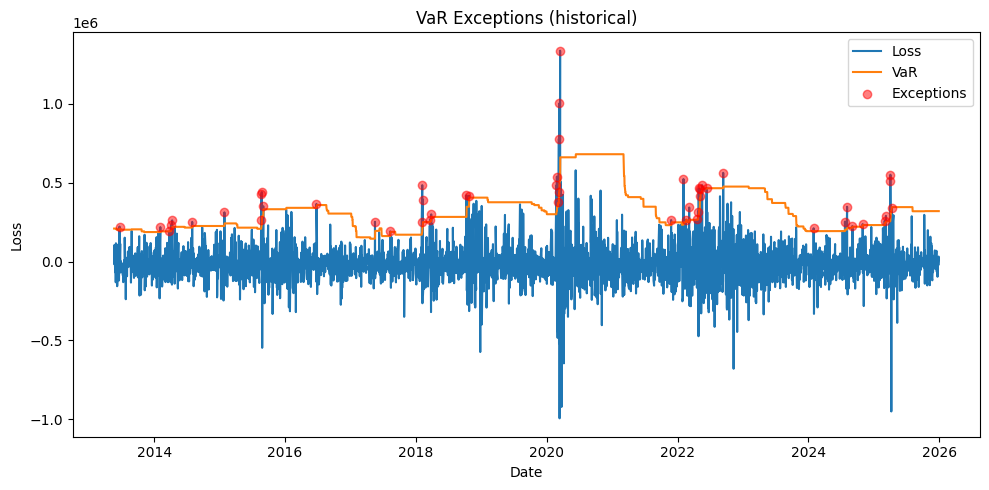

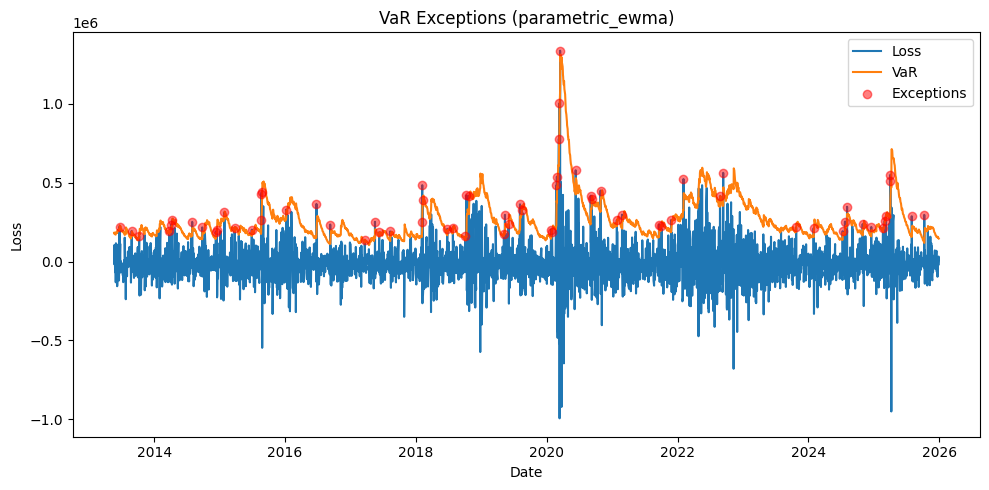

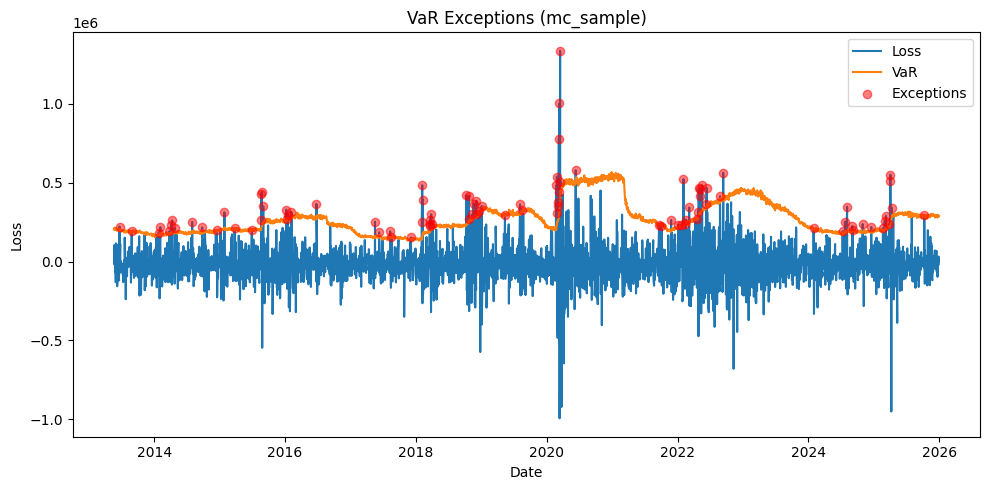

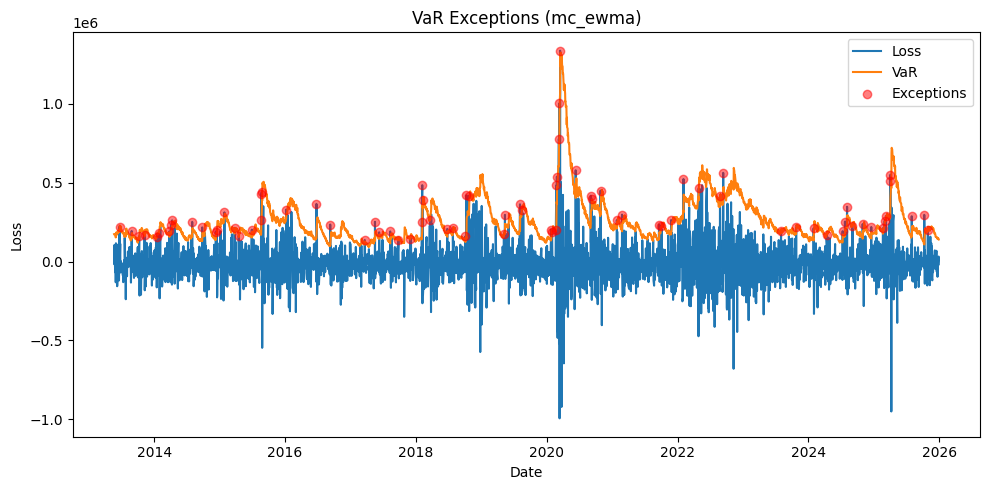

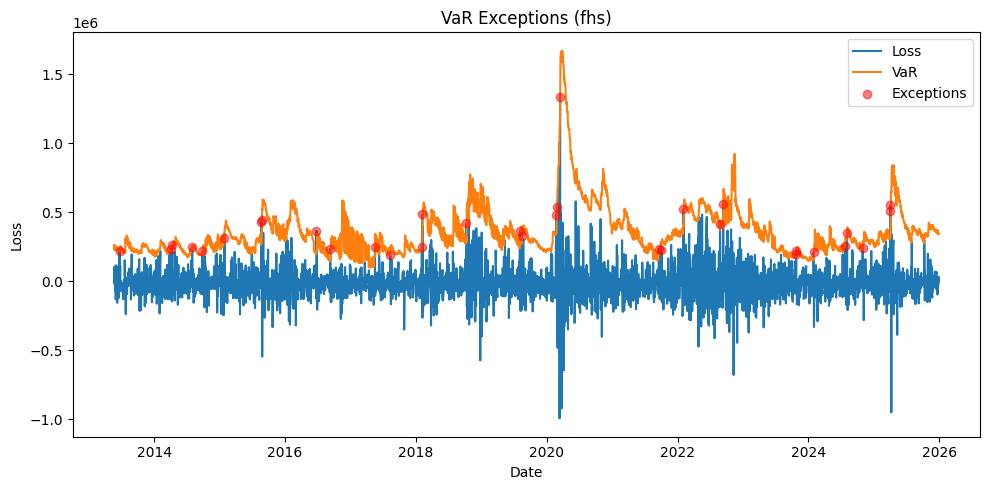

In [5]:
plot_exceptions(bt_hist)
plot_exceptions(bt_ewma)
plot_exceptions(bt_mc_sample)
plot_exceptions(bt_mc_ewma)
plot_exceptions(bt_fhs)

### Model Comparisons

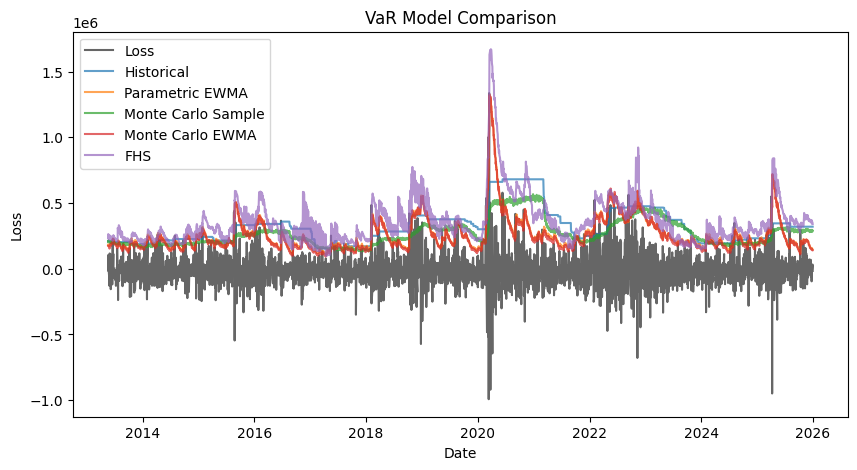

In [6]:
plot_var_comparison({
    "Historical": bt_hist,
    "Parametric EWMA": bt_ewma,
    "Monte Carlo Sample": bt_mc_sample,
    "Monte Carlo EWMA": bt_mc_ewma,
    "FHS": bt_fhs
})

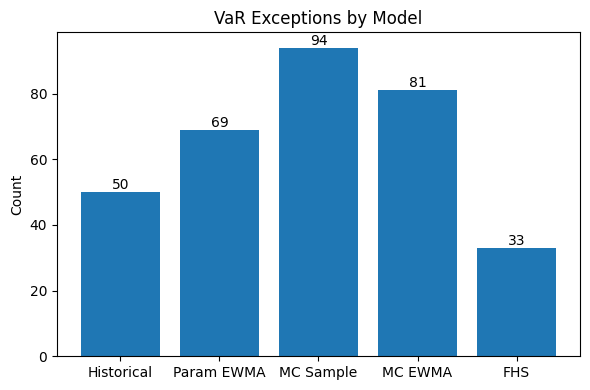

In [7]:
plot_exception_counts({
    "Historical": bt_hist,
    "Param EWMA": bt_ewma,
    "MC Sample": bt_mc_sample,
    "MC EWMA": bt_mc_ewma,
    "FHS": bt_fhs
})

The historical VaR tracks realized losses reasonably well but exhibits several clustered exceptions during periods of elevated volatility. 

The parametric VaR with EWMA covariance underestimates tail risk due to the normality assumption, resulting in a higher exception rate.

The Monte Carlo VaR with EWMA covariance behaves as expected, performing similarly as EWMA parametric since they share the same underlying normality assumption.

The filtered historical simulation model improves responsiveness to volatility regimes and produces exception frequencies closer to the expected level.